# Prédiction d'AVC — Pipeline complet de Machine Learning
### Dataset : `healthcare-dataset-stroke-data.csv`
---
> **Objectif** : Prédire si un patient est susceptible de subir un AVC `stroke = 1` à partir de données cliniques et socio-démographiques.  
> Ce notebook couvre l'ensemble du pipeline : EDA → Prétraitement → Modélisation → Évaluation.


---
## 1.  Chargement et compréhension des données
### 1.1 Import des bibliothèques


In [33]:
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Prétraitement
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Évaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc, roc_auc_score)

# Gestion du déséquilibre
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Divers
import warnings
warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print(" Bibliothèques importées avec succès !")


 Bibliothèques importées avec succès !


### 1.2 Chargement du dataset

In [34]:
# Chargement
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print(f" Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print()
df.head(10)


 Dimensions : 5110 lignes × 12 colonnes



,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


### 1.3 Structure et types de variables

In [35]:
# Informations générales
print("=" * 55)
print("INFORMATIONS GÉNÉRALES")
print("=" * 55)
df.info()


INFORMATIONS GÉNÉRALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [36]:
# Types de variables et cardinalité
print("\n Types de variables :")
print("-" * 45)
for col in df.columns:
    dtype = df[col].dtype
    n_unique = df[col].nunique()
    var_type = "Catégorielle" if dtype == 'object' else "Numérique"
    print(f"  {col:<22} | {str(dtype):<10} | {var_type:<14} | {n_unique} valeurs uniques")

# Variable cible
print("\n Variable cible : 'stroke'")
print(f"   → 0 = Pas d'AVC  |  1 = AVC")
print(f"   → Distribution : {df['stroke'].value_counts().to_dict()}")



 Types de variables :
---------------------------------------------
  id                     | int64      | Numérique      | 5110 valeurs uniques
  gender                 | object     | Catégorielle   | 3 valeurs uniques
  age                    | float64    | Numérique      | 104 valeurs uniques
  hypertension           | int64      | Numérique      | 2 valeurs uniques
  heart_disease          | int64      | Numérique      | 2 valeurs uniques
  ever_married           | object     | Catégorielle   | 2 valeurs uniques
  work_type              | object     | Catégorielle   | 5 valeurs uniques
  Residence_type         | object     | Catégorielle   | 2 valeurs uniques
  avg_glucose_level      | float64    | Numérique      | 3979 valeurs uniques
  bmi                    | float64    | Numérique      | 418 valeurs uniques
  smoking_status         | object     | Catégorielle   | 4 valeurs uniques
  stroke                 | int64      | Numérique      | 2 valeurs uniques

 Variable cible : 's

---
## 2.  Analyse Exploratoire des Données (EDA)
### 2.1 Statistiques descriptives


In [37]:
# Statistiques sur les variables numériques
print(" Statistiques descriptives — Variables numériques")
df.describe().round(2)


 Statistiques descriptives — Variables numériques


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.00,5110.00,5110.0,5110.00,5110.00,4909.00,5110.00
mean,36517.83,43.23,0.1,0.05,106.15,28.89,0.05
std,21161.72,22.61,0.3,0.23,45.28,7.85,0.22
min,67.00,0.08,0.0,0.00,55.12,10.30,0.00
25%,17741.25,25.00,0.0,0.00,77.24,23.50,0.00
50%,36932.00,45.00,0.0,0.00,91.88,28.10,0.00
75%,54682.00,61.00,0.0,0.00,114.09,33.10,0.00
max,72940.00,82.00,1.0,1.00,271.74,97.60,1.00


In [38]:
# Statistiques sur les variables catégorielles
print(" Statistiques descriptives — Variables catégorielles\n")
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f" {col} :")
    print(df[col].value_counts().to_string(), "\n")


 Statistiques descriptives — Variables catégorielles

 gender :
gender
Female    2994
Male      2115
Other        1 

 ever_married :
ever_married
Yes    3353
No     1757 

 work_type :
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22 

 Residence_type :
Residence_type
Urban    2596
Rural    2514 

 smoking_status :
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789 



### 2.2 Analyse des valeurs manquantes

 Valeurs manquantes :


,Manquant,% Total
bmi,201,3.93


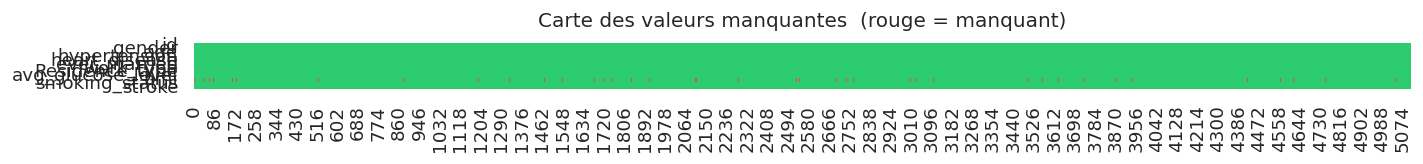


 La colonne 'bmi' contient 201 valeurs manquantes (3.93% du total).


In [39]:
# Visualisation des valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquant': missing, '% Total': missing_pct})
missing_df = missing_df[missing_df['Manquant'] > 0]

print(" Valeurs manquantes :")
if missing_df.empty:
    print("  Aucune valeur manquante sauf :")

display(missing_df)

# Heatmap
fig, ax = plt.subplots(figsize=(12, 1.5))
sns.heatmap(df.isnull().T, cbar=False, ax=ax,
            cmap=['#2ecc71', '#e74c3c'], yticklabels=df.columns)
ax.set_title("Carte des valeurs manquantes  (rouge = manquant)", fontsize=12, pad=10)
plt.tight_layout()
plt.show()
print(f"\n La colonne 'bmi' contient {missing['bmi']} valeurs manquantes ({missing_pct['bmi']}% du total).")


### 2.3 Analyse des variables catégorielles

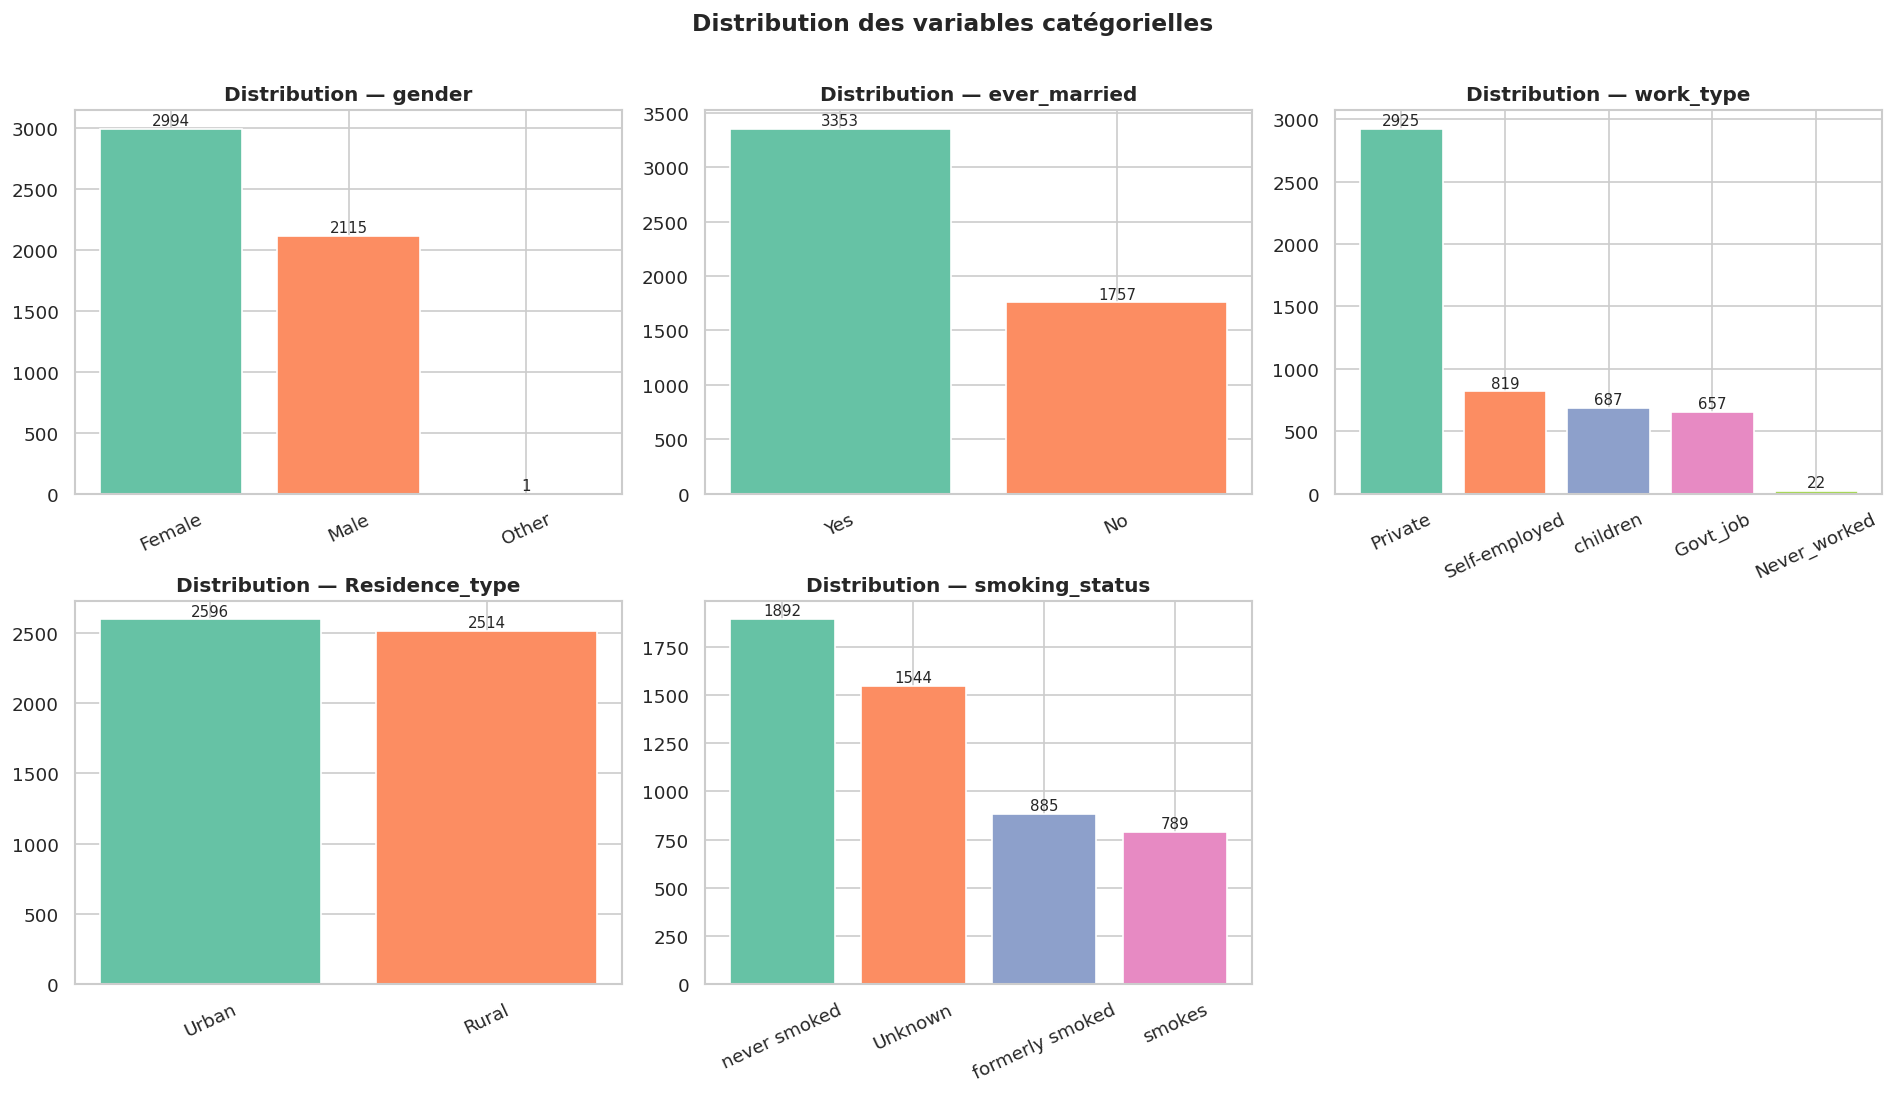

In [40]:
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values,
                       color=sns.color_palette('Set2', len(counts)))
    axes[i].set_title(f'Distribution — {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=25)
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., h + 5,
                     f'{int(h)}', ha='center', va='bottom', fontsize=9)

axes[-1].axis('off')
fig.suptitle('Distribution des variables catégorielles', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 2.4 Analyse des variables numériques

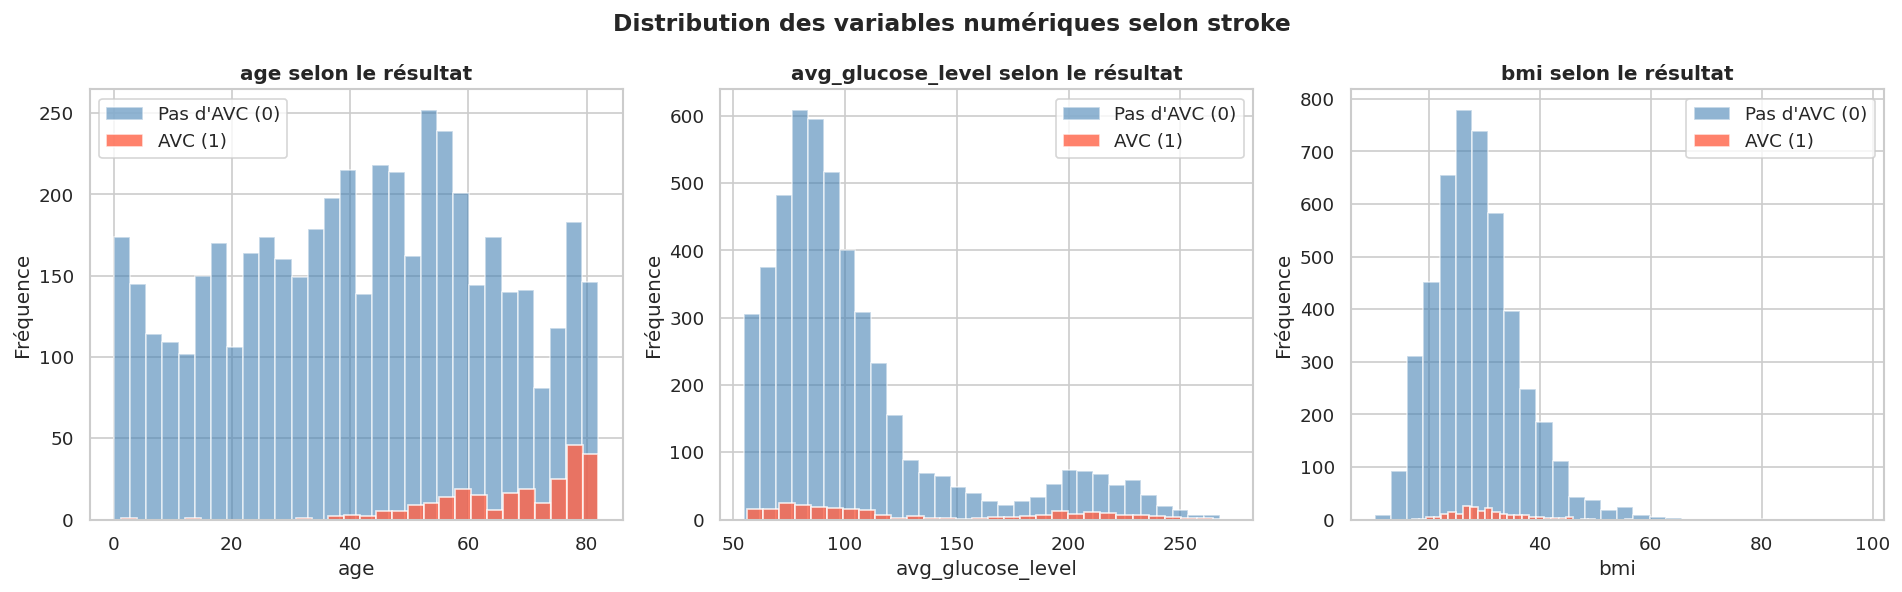

In [41]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    data_no = df[df['stroke'] == 0][col].dropna()
    data_yes = df[df['stroke'] == 1][col].dropna()
    axes[i].hist(data_no, bins=30, alpha=0.6, color='steelblue', label='Pas d\'AVC (0)')
    axes[i].hist(data_yes, bins=30, alpha=0.8, color='tomato', label='AVC (1)')
    axes[i].set_title(f'{col} selon le résultat', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')
    axes[i].legend()

fig.suptitle('Distribution des variables numériques selon stroke', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 3.  Étude des distributions
### 3.1 Histogrammes complets


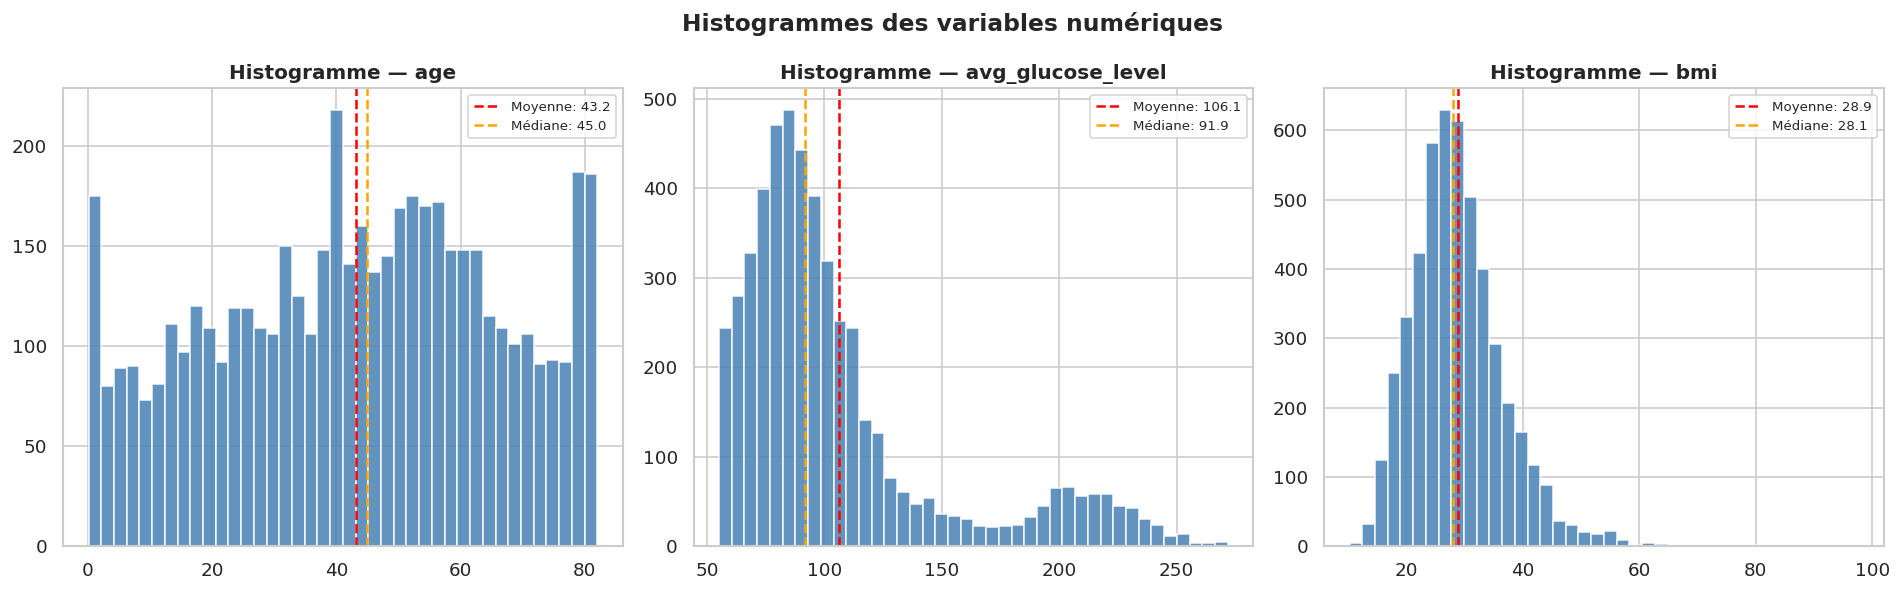

In [42]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Moyenne: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', label=f'Médiane: {df[col].median():.1f}')
    axes[i].set_title(f'Histogramme — {col}', fontweight='bold')
    axes[i].legend(fontsize=8)

fig.suptitle('Histogrammes des variables numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.2 Boxplots

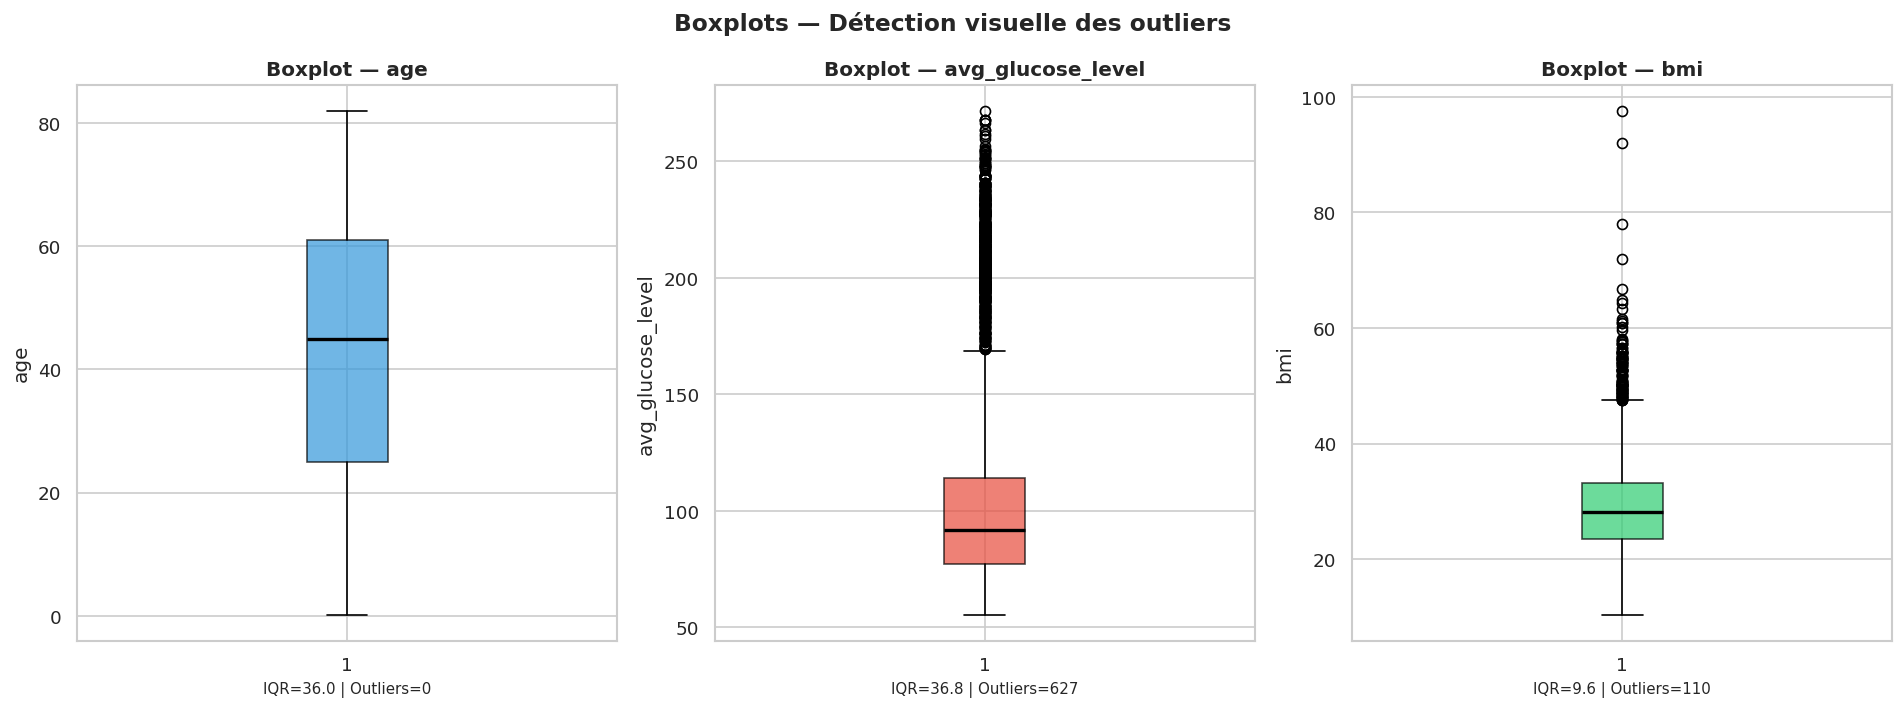

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, col in enumerate(num_cols):
    bp = axes[i].boxplot(df[col].dropna(), patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(colors[i])
    bp['boxes'][0].set_alpha(0.7)
    axes[i].set_title(f'Boxplot — {col}', fontweight='bold')
    axes[i].set_ylabel(col)

    # Statistiques dans le titre
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)][col]
    axes[i].set_xlabel(f'IQR={iqr:.1f} | Outliers={len(outliers)}', fontsize=9)

fig.suptitle('Boxplots — Détection visuelle des outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.3 Analyse des outliers

In [44]:

print("ANALYSE DES OUTLIERS (méthode IQR)")

outlier_summary = {}
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(out)
    print(f"\n {col}")
    print(f"   Q1={q1:.1f} | Q3={q3:.1f} | IQR={iqr:.1f}")
    print(f"   Borne inf={lower:.1f} | Borne sup={upper:.1f}")
    print(f"   Nombre d'outliers : {len(out)} ({len(out)/len(df)*100:.1f}%)")

print("\n Interprétation :")
print("   'bmi' présente des valeurs extrêmes mais plausibles médicalement.")
print("   'avg_glucose_level' montre une queue droite (diabète non diagnostiqué).")
print("   Les outliers seront conservés car ils ont une signification clinique réelle.")


ANALYSE DES OUTLIERS (méthode IQR)

 age
   Q1=25.0 | Q3=61.0 | IQR=36.0
   Borne inf=-29.0 | Borne sup=115.0
   Nombre d'outliers : 0 (0.0%)

 avg_glucose_level
   Q1=77.2 | Q3=114.1 | IQR=36.8
   Borne inf=22.0 | Borne sup=169.4
   Nombre d'outliers : 627 (12.3%)

 bmi
   Q1=23.5 | Q3=33.1 | IQR=9.6
   Borne inf=9.1 | Borne sup=47.5
   Nombre d'outliers : 110 (2.2%)

 Interprétation :
   'bmi' présente des valeurs extrêmes mais plausibles médicalement.
   'avg_glucose_level' montre une queue droite (diabète non diagnostiqué).
   Les outliers seront conservés car ils ont une signification clinique réelle.


---
## 4.  Analyse de corrélation
### 4.1 Préparation — encodage temporaire pour la corrélation


In [45]:
# Copie temporaire pour l'analyse de corrélation
df_corr = df.copy()

# Encodage label des catégorielles
le = LabelEncoder()
cat_cols = df_corr.select_dtypes(include='object').columns
for col in cat_cols:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# Imputation temporaire de bmi par la médiane
df_corr['bmi'] = df_corr['bmi'].fillna(df_corr['bmi'].median())

print(" Encodage temporaire appliqué pour la matrice de corrélation.")


 Encodage temporaire appliqué pour la matrice de corrélation.


### 4.2 Matrice de corrélation (heatmap)

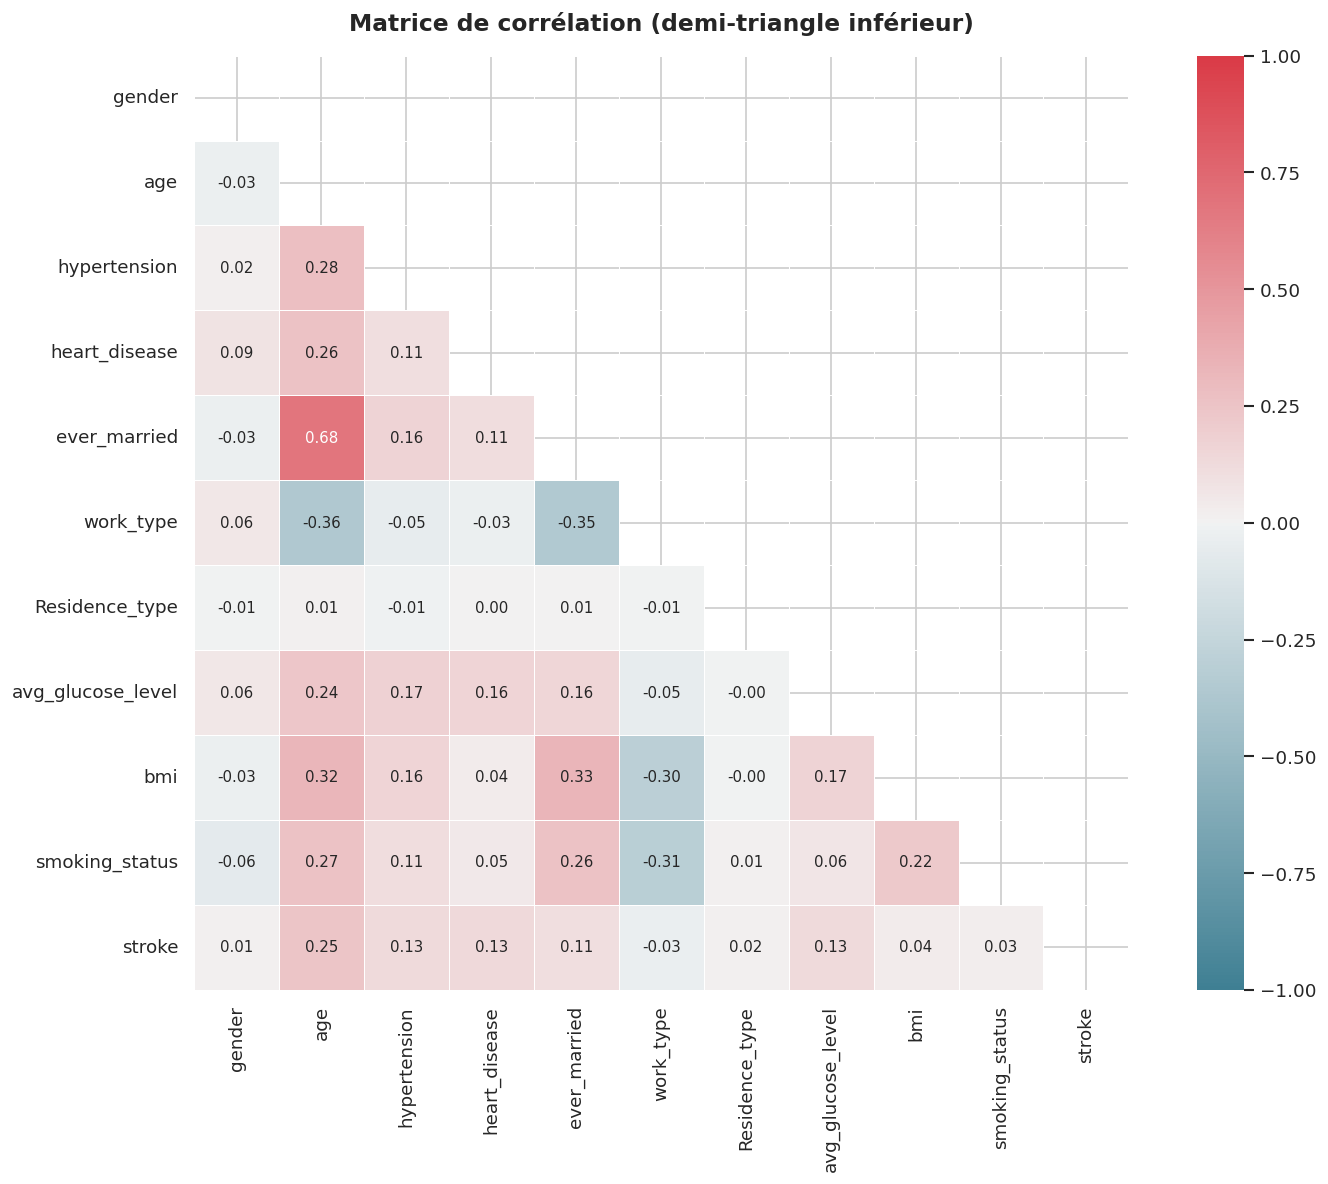

In [46]:
# Calcul de la matrice
corr_matrix = df_corr.drop(columns=['id']).corr()

# Visualisation
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', square=True, linewidths=.5,
            annot_kws={'size': 9}, ax=ax)

ax.set_title('Matrice de corrélation (demi-triangle inférieur)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### 4.3 Variables les plus corrélées avec la cible

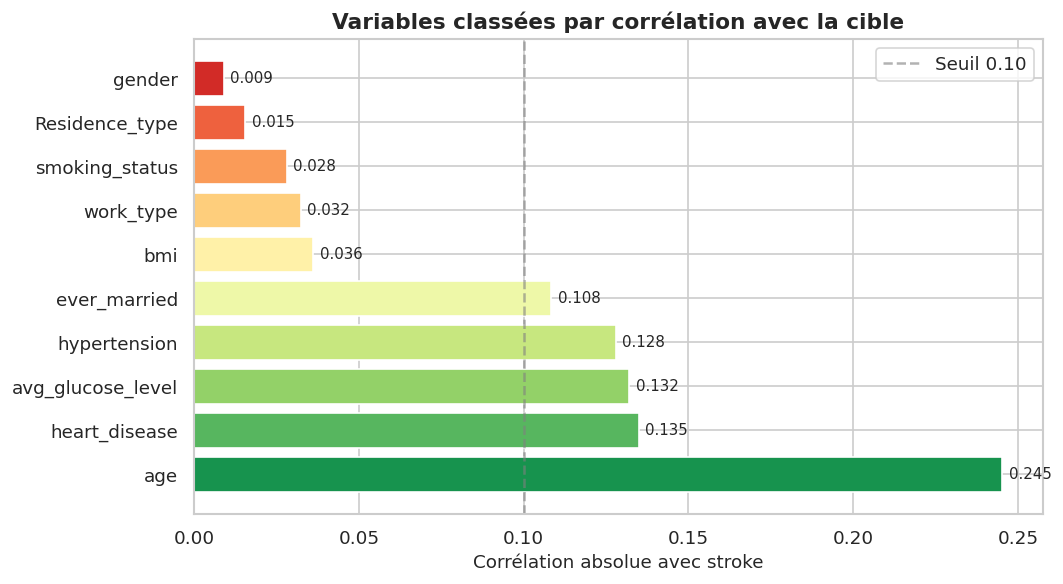


 Top 5 variables les plus corrélées avec stroke :
   age                       → 0.2453
   heart_disease             → 0.1349
   avg_glucose_level         → 0.1319
   hypertension              → 0.1279
   ever_married              → 0.1083


In [47]:
# Corrélation avec 'stroke'
target_corr = corr_matrix['stroke'].drop('stroke').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(target_corr.index, target_corr.values,
               color=[sns.color_palette('RdYlGn_r', 10)[i] for i in range(len(target_corr))])
ax.set_xlabel('Corrélation absolue avec stroke', fontsize=11)
ax.set_title('Variables classées par corrélation avec la cible', fontsize=13, fontweight='bold')
ax.axvline(0.1, color='gray', linestyle='--', alpha=0.6, label='Seuil 0.10')
ax.legend()

for bar, val in zip(bars, target_corr.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n Top 5 variables les plus corrélées avec stroke :")
for var, val in target_corr.head(5).items():
    print(f"   {var:<25} → {val:.4f}")


---
## 5.  Prétraitement et nettoyage
### 5.1 Traitement des valeurs manquantes


In [48]:
df_clean = df.copy()

# Imputation de 'bmi' par la médiane (robuste aux outliers)
median_bmi = df_clean['bmi'].median()
df_clean['bmi'] = df_clean['bmi'].fillna(median_bmi)

print(f" 'bmi' : {df['bmi'].isnull().sum()} valeurs manquantes imputées par la médiane ({median_bmi:.1f})")
print(f"   Valeurs manquantes restantes : {df_clean.isnull().sum().sum()}")


 'bmi' : 201 valeurs manquantes imputées par la médiane (28.1)
   Valeurs manquantes restantes : 0


### 5.2 Suppression des lignes non pertinentes

In [49]:
# Supprimer la ligne 'Other' dans gender (1 seule occurrence, non binaire)
before = len(df_clean)
df_clean = df_clean[df_clean['gender'] != 'Other']
print(f" Ligne(s) supprimée(s) (gender='Other') : {before - len(df_clean)}")
print(f"   Nouveau shape : {df_clean.shape}")


 Ligne(s) supprimée(s) (gender='Other') : 1
   Nouveau shape : (5109, 12)


### 5.3 Encodage des variables catégorielles

In [50]:
# Suppression de la colonne ID (non informative)
df_clean = df_clean.drop(columns=['id'])

# Label Encoding pour les variables binaires
le = LabelEncoder()
binary_cols = ['gender', 'ever_married', 'Residence_type']
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f" Label Encoding — '{col}' : {dict(zip(le.classes_, le.transform(le.classes_)))}")

# One-Hot Encoding pour les variables à > 2 modalités
df_clean = pd.get_dummies(df_clean, columns=['work_type', 'smoking_status'], drop_first=False)
print(f"\n One-Hot Encoding appliqué à : 'work_type', 'smoking_status'")
print(f"\n Shape après encodage : {df_clean.shape}")
df_clean.head(3)


 Label Encoding — 'gender' : {'Female': np.int64(0), 'Male': np.int64(1)}
 Label Encoding — 'ever_married' : {'No': np.int64(0), 'Yes': np.int64(1)}
 Label Encoding — 'Residence_type' : {'Rural': np.int64(0), 'Urban': np.int64(1)}

 One-Hot Encoding appliqué à : 'work_type', 'smoking_status'

 Shape après encodage : (5109, 18)


,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,1,228.69,36.6,1,False,False,True,False,False,False,True,False,False
1,0,61.0,0,0,1,0,202.21,28.1,1,False,False,False,True,False,False,False,True,False
2,1,80.0,0,1,1,0,105.92,32.5,1,False,False,True,False,False,False,False,True,False


---
## 6.  Standardisation et normalisation


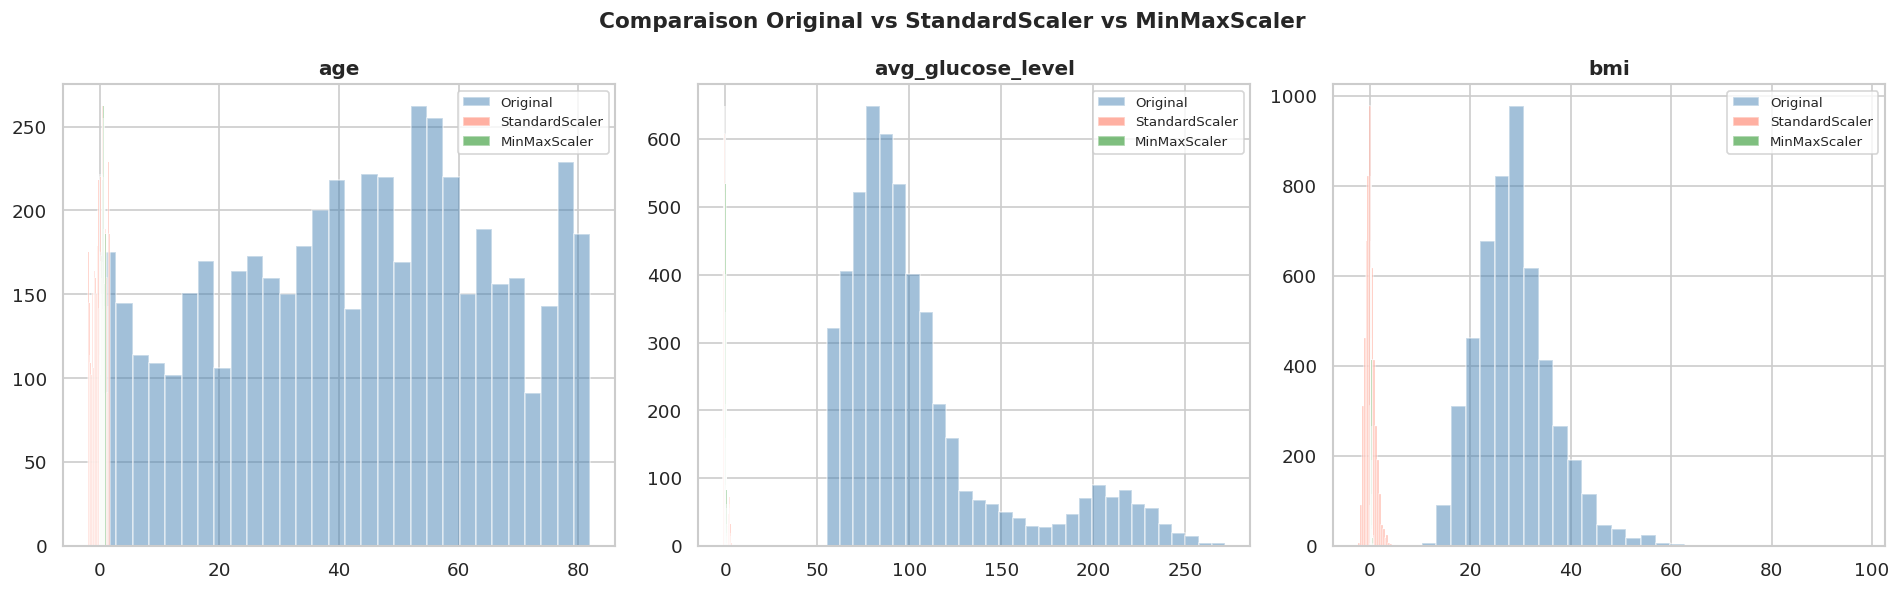


 Résumé après StandardScaler :
            age  avg_glucose_level       bmi
count  5109.000           5109.000  5109.000
mean      0.000             -0.000    -0.000
std       1.000              1.000     1.000
min      -1.908             -1.127    -2.411
25%      -0.806             -0.638    -0.658
50%       0.078             -0.315    -0.099
75%       0.786              0.176     0.511
max       1.715              3.657     8.928

 Résumé après MinMaxScaler :
            age  avg_glucose_level       bmi
count  5109.000           5109.000  5109.000
mean      0.527              0.236     0.213
std       0.276              0.209     0.088
min       0.000              0.000     0.000
25%       0.304              0.102     0.155
50%       0.548              0.170     0.204
75%       0.744              0.272     0.258
max       1.000              1.000     1.000

 Choix : StandardScaler est préféré ici (adapté aux SVM, régression logistique).


In [51]:
# Séparation features / target
X = df_clean.drop(columns=['stroke'])
y = df_clean['stroke']

features_to_scale = ['age', 'avg_glucose_level', 'bmi']

# StandardScaler
scaler_std = StandardScaler()
X_std = X.copy()
X_std[features_to_scale] = scaler_std.fit_transform(X[features_to_scale])

# MinMaxScaler
scaler_mm = MinMaxScaler()
X_mm = X.copy()
X_mm[features_to_scale] = scaler_mm.fit_transform(X[features_to_scale])

# Comparaison visuelle
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(features_to_scale):
    axes[i].hist(X[col], bins=30, alpha=0.5, color='steelblue', label='Original')
    axes[i].hist(X_std[col], bins=30, alpha=0.5, color='tomato', label='StandardScaler')
    axes[i].hist(X_mm[col], bins=30, alpha=0.5, color='green', label='MinMaxScaler')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].legend(fontsize=8)

fig.suptitle('Comparaison Original vs StandardScaler vs MinMaxScaler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Résumé après StandardScaler :")
print(X_std[features_to_scale].describe().round(3))
print("\n Résumé après MinMaxScaler :")
print(X_mm[features_to_scale].describe().round(3))

print("\n Choix : StandardScaler est préféré ici (adapté aux SVM, régression logistique).")


---
## 7.  Gestion du déséquilibre des classes
### 7.1 Distribution initiale


Distribution de la variable cible :
stroke
0    4860
1     249
Name: count, dtype: int64

Ratio : 19.5:1 (pas d'AVC vs AVC)


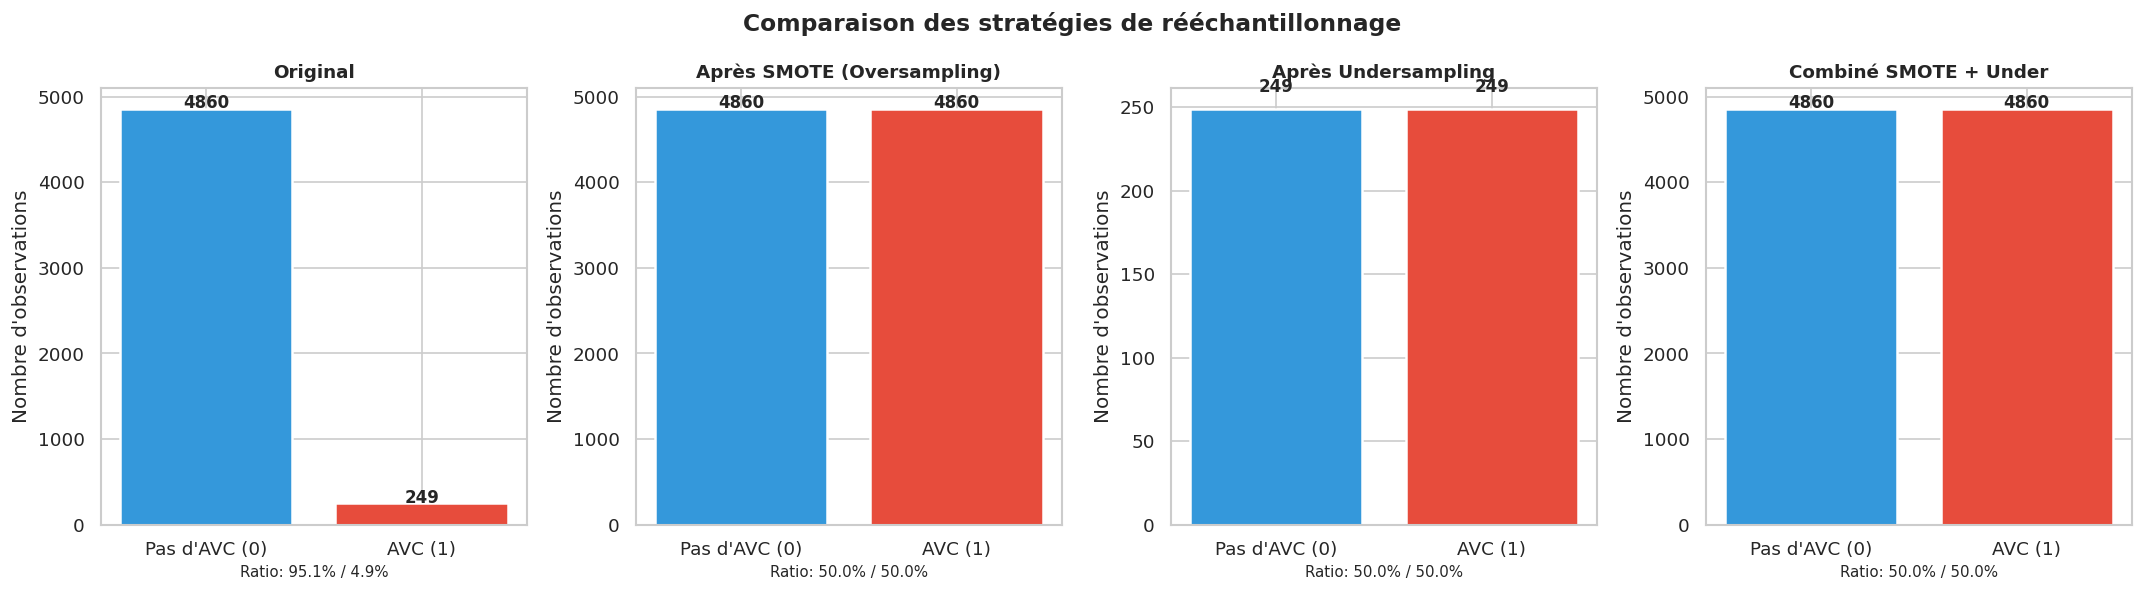


 Stratégie retenue : SMOTE (oversampling)
   → Dataset SMOTE : 9720 lignes | Classes : {1: np.int64(4860), 0: np.int64(4860)}


In [67]:
print("Distribution de la variable cible :")
print(y.value_counts())
print(f"\nRatio : {y.value_counts()[0]/y.value_counts()[1]:.1f}:1 (pas d'AVC vs AVC)")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

def plot_distribution(ax, y_data, title):
    counts = pd.Series(y_data).value_counts().sort_index()
    colors = ['#3498db', '#e74c3c']
    bars = ax.bar(['Pas d\'AVC (0)', 'AVC (1)'], counts.values,
                  color=colors, edgecolor='white', linewidth=1.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 10,
                f'{int(h)}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel("Nombre d'observations")
    total = counts.sum()
    ax.set_xlabel(f"Ratio: {counts[0]/total*100:.1f}% / {counts[1]/total*100:.1f}%", fontsize=9)

plot_distribution(axes[0], y, "Original")

# SMOTE (Oversampling)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_std, y)
plot_distribution(axes[1], y_smote, "Après SMOTE (Oversampling)")

# Undersampling
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_std, y)
plot_distribution(axes[2], y_under, "Après Undersampling")

# Combiné SMOTE + Under
X_comb, y_comb = smote.fit_resample(X_std, y)
rus2 = RandomUnderSampler(random_state=42, sampling_strategy=1)
X_comb, y_comb = rus2.fit_resample(X_comb, y_comb)
plot_distribution(axes[3], y_comb, "Combiné SMOTE + Under")

fig.suptitle('Comparaison des stratégies de rééchantillonnage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Stratégie retenue : SMOTE (oversampling)")
print(f"   → Dataset SMOTE : {X_smote.shape[0]} lignes | Classes : {dict(pd.Series(y_smote).value_counts())}")


---
## 8. Split des données
### 8.1 Train / Test Split


In [53]:
# Split principal (stratifié) sur les données SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

print(f" Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"   Train — Classe 0: {(y_train==0).sum()}  |  Classe 1: {(y_train==1).sum()}")
print(f"   Test  — Classe 0: {(y_test==0).sum()}   |  Classe 1: {(y_test==1).sum()}")


 Train : (7776, 17)  |  Test : (1944, 17)
   Train — Classe 0: 3888  |  Classe 1: 3888
   Test  — Classe 0: 972   |  Classe 1: 972


### 8.2 K-Fold et Stratified K-Fold

In [54]:
# K-Fold standard
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print("K-Fold (5 splits) — exemple de splits :")
for i, (train_idx, val_idx) in enumerate(kf.split(X_smote)):
    print(f"  Fold {i+1} : Train={len(train_idx)} | Val={len(val_idx)}")

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\nStratified K-Fold (5 splits) — distribution par fold :")
for i, (train_idx, val_idx) in enumerate(skf.split(X_smote, y_smote)):
    y_val_fold = y_smote.iloc[val_idx]
    print(f"  Fold {i+1} : Val={len(val_idx)} | Classe 0={sum(y_val_fold==0)} | Classe 1={sum(y_val_fold==1)}")

print("\n Stratified K-Fold préservé la proportion des classes → recommandé ici.")


K-Fold (5 splits) — exemple de splits :
  Fold 1 : Train=7776 | Val=1944
  Fold 2 : Train=7776 | Val=1944
  Fold 3 : Train=7776 | Val=1944
  Fold 4 : Train=7776 | Val=1944
  Fold 5 : Train=7776 | Val=1944

Stratified K-Fold (5 splits) — distribution par fold :
  Fold 1 : Val=1944 | Classe 0=972 | Classe 1=972
  Fold 2 : Val=1944 | Classe 0=972 | Classe 1=972
  Fold 3 : Val=1944 | Classe 0=972 | Classe 1=972
  Fold 4 : Val=1944 | Classe 0=972 | Classe 1=972
  Fold 5 : Val=1944 | Classe 0=972 | Classe 1=972

 Stratified K-Fold préservé la proportion des classes → recommandé ici.


---
## 9.  Définition et entraînement des modèles


In [55]:
# Définition des modèles
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=7)
}

# Entraînement + stockage des résultats
results = {}
trained_models = {}

print("=" * 50)
print("ENTRAÎNEMENT DES MODÈLES")
print("=" * 50)

for name, model in models.items():
    # Cross-validation (Stratified K-Fold)
    cv_scores = cross_val_score(model, X_train, y_train,
                                 cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                 scoring='f1')
    # Entraînement sur train complet
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'auc':       roc_auc_score(y_test, y_prob),
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std':  cv_scores.std()
    }
    print(f"\n {name}")
    print(f"   Accuracy={results[name]['accuracy']:.3f} | F1={results[name]['f1']:.3f} | AUC={results[name]['auc']:.3f}")
    print(f"   CV F1 = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


ENTRAÎNEMENT DES MODÈLES

 Logistic Regression
   Accuracy=0.826 | F1=0.830 | AUC=0.907
   CV F1 = 0.822 ± 0.012

 Decision Tree
   Accuracy=0.861 | F1=0.872 | AUC=0.908
   CV F1 = 0.865 ± 0.006

 Random Forest
   Accuracy=0.948 | F1=0.950 | AUC=0.991
   CV F1 = 0.939 ± 0.004

 SVM
   Accuracy=0.876 | F1=0.882 | AUC=0.941
   CV F1 = 0.876 ± 0.004

 KNN
   Accuracy=0.887 | F1=0.897 | AUC=0.963
   CV F1 = 0.893 ± 0.002


---
## 10.  Évaluation des modèles
### 10.1 Tableau récapitulatif des métriques


In [56]:
metrics_df = pd.DataFrame({
    name: {
        'Accuracy':  r['accuracy'],
        'Precision': r['precision'],
        'Recall':    r['recall'],
        'F1-Score':  r['f1'],
        'AUC-ROC':   r['auc'],
        'CV F1 (mean)': r['cv_f1_mean'],
        'CV F1 (std)':  r['cv_f1_std']
    }
    for name, r in results.items()
}).T.round(4)

print(" Métriques de performance :")
display(metrics_df.style.background_gradient(cmap='YlGn', subset=['Accuracy','F1-Score','AUC-ROC'])
        .format("{:.4f}"))


 Métriques de performance :


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,CV F1 (mean),CV F1 (std)
Logistic Regression,0.8261,0.8108,0.8508,0.8303,0.9067,0.8216,0.0116
Decision Tree,0.8606,0.8066,0.9486,0.8719,0.9084,0.8653,0.0055
Random Forest,0.9480,0.9167,0.9856,0.9499,0.9907,0.9391,0.0038
SVM,0.8755,0.8373,0.9321,0.8822,0.9405,0.8757,0.0041
KNN,0.8873,0.8243,0.9846,0.8973,0.9631,0.8932,0.0019


### 10.2 Matrices de confusion

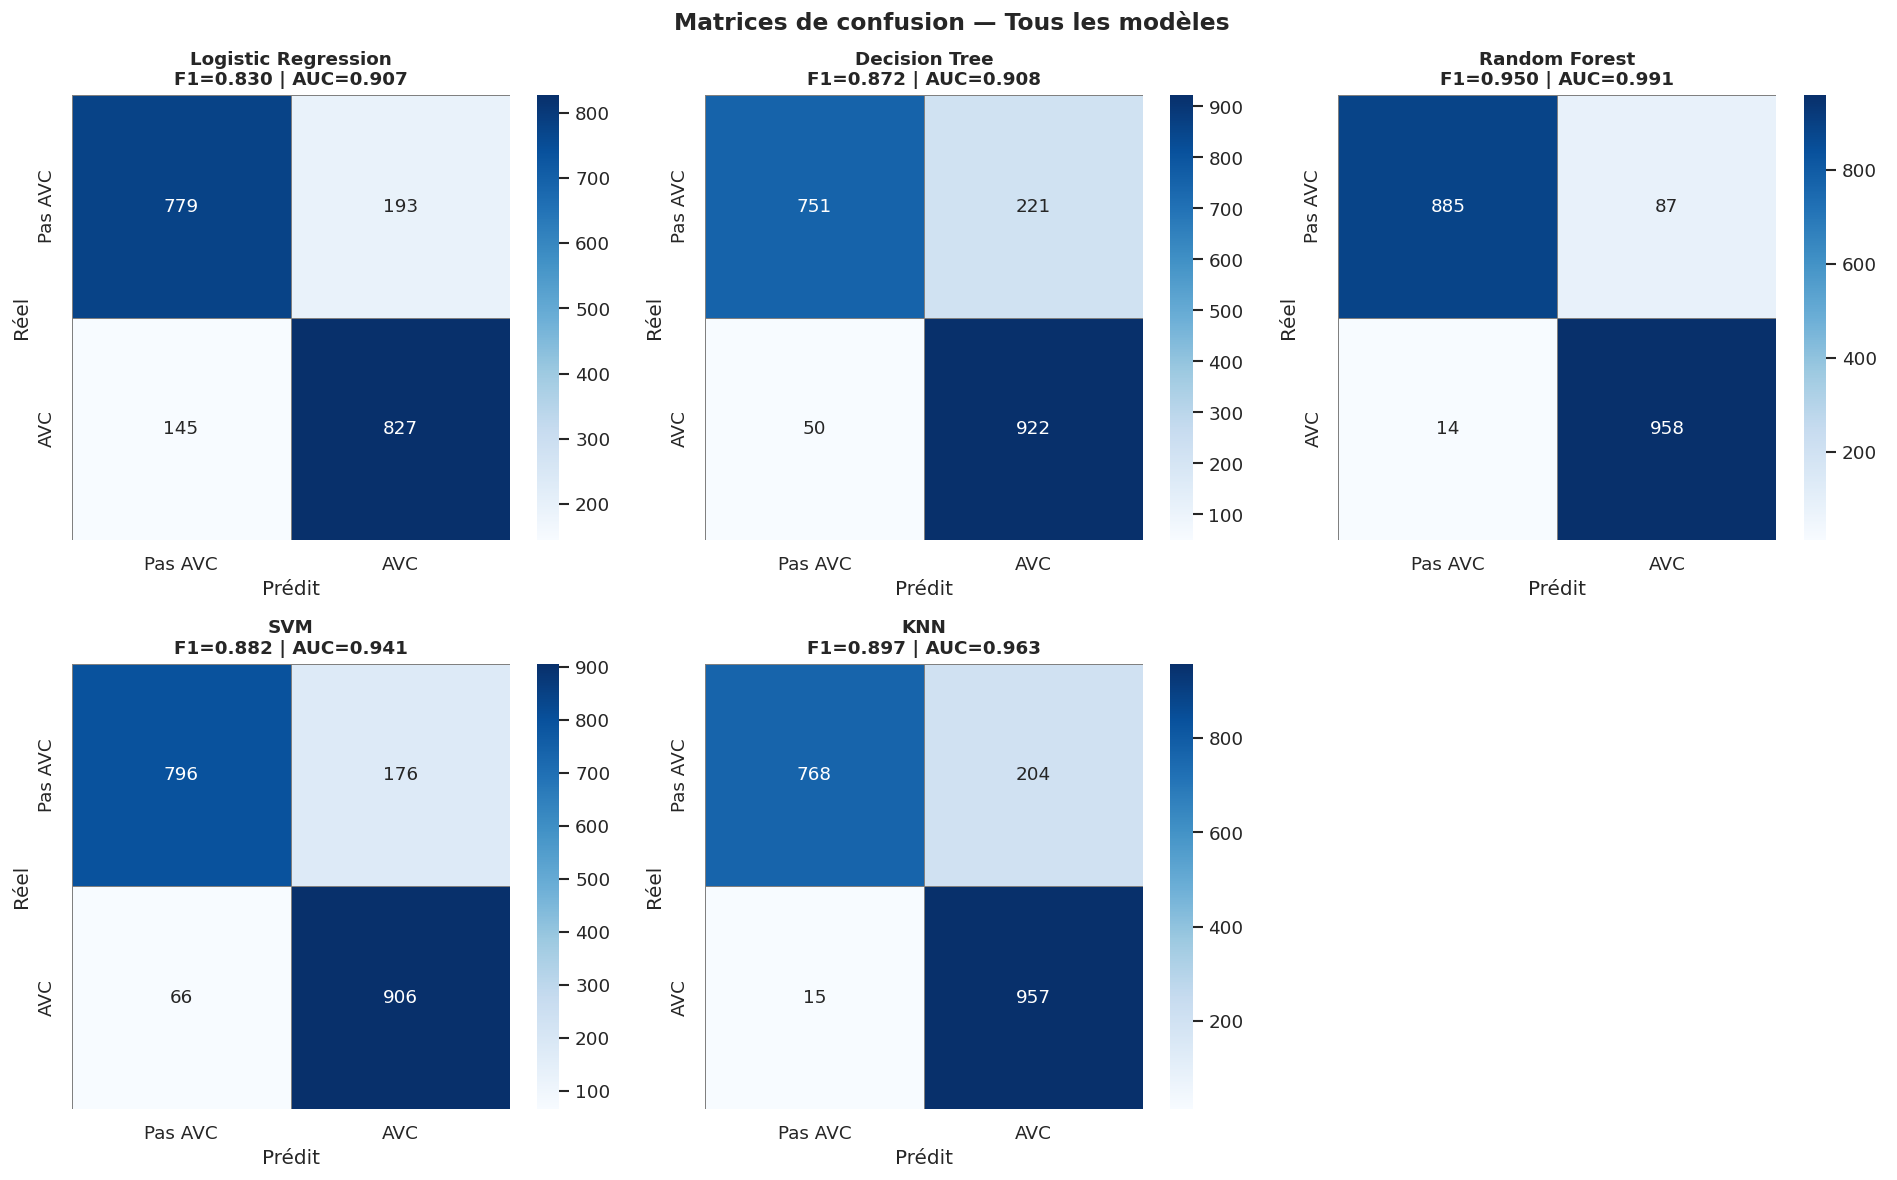

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Pas AVC', 'AVC'],
                yticklabels=['Pas AVC', 'AVC'],
                linewidths=0.5, linecolor='gray')
    axes[i].set_title(f'{name}\nF1={r["f1"]:.3f} | AUC={r["auc"]:.3f}',
                      fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')

axes[-1].axis('off')
fig.suptitle('Matrices de confusion — Tous les modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 10.3 Courbes ROC

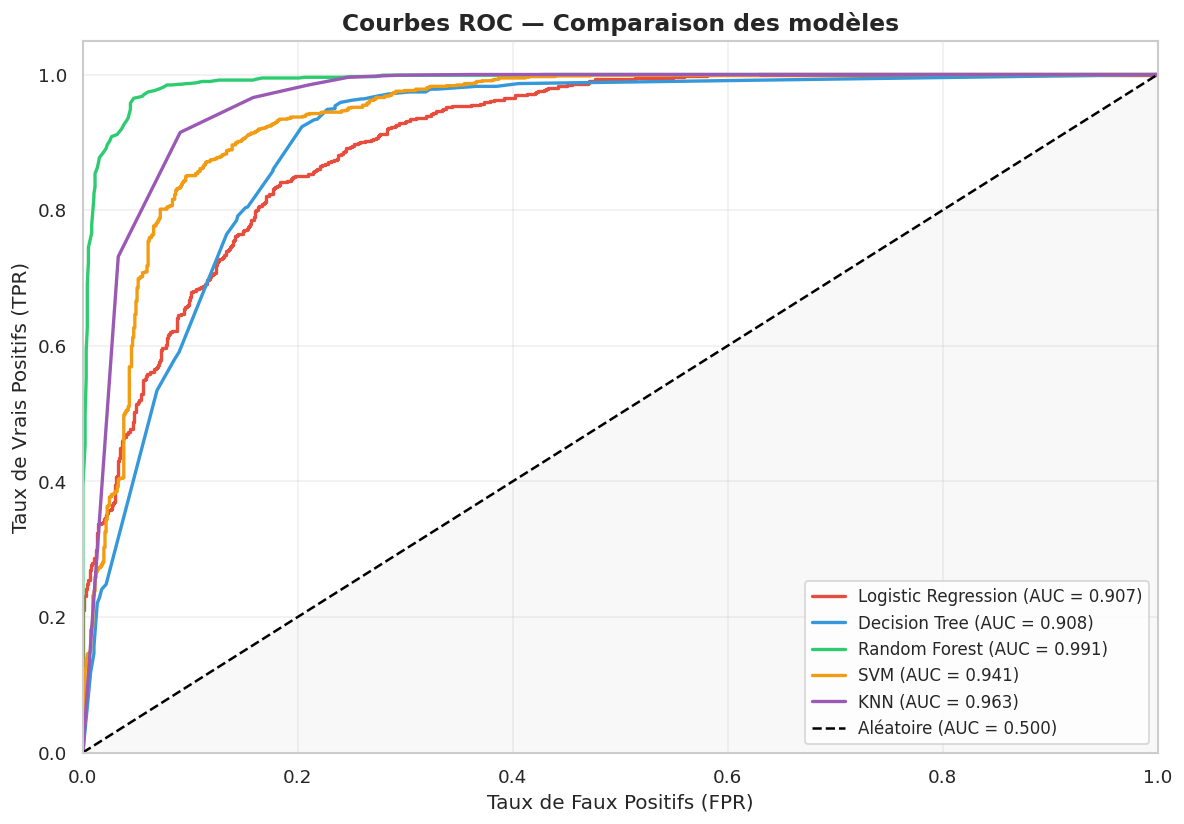

In [58]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aléatoire (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
ax.set_title('Courbes ROC — Comparaison des modèles', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 10.4 Comparaison visuelle des performances

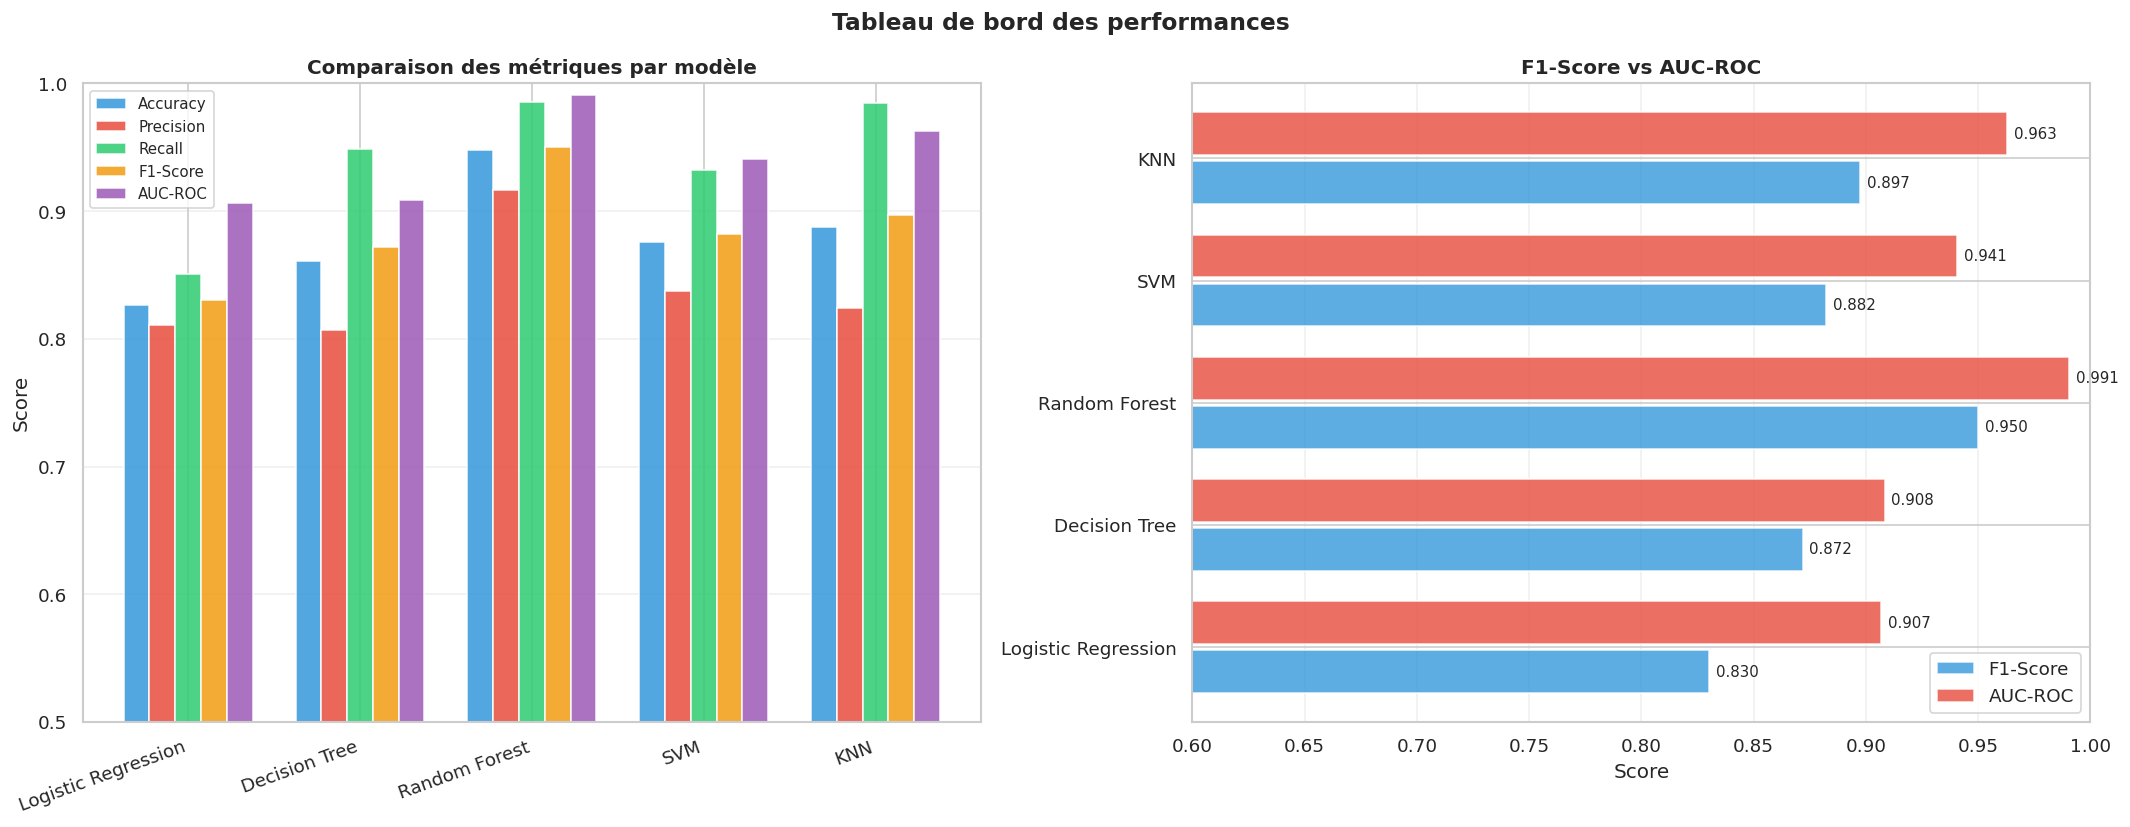

In [59]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
model_names = list(results.keys())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Grouped bar chart
x = np.arange(len(model_names))
width = 0.15
bars_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (metric, color) in enumerate(zip(metric_names, bars_colors)):
    key_map = {'Accuracy':'accuracy','Precision':'precision',
               'Recall':'recall','F1-Score':'f1','AUC-ROC':'auc'}
    vals = [results[m][key_map[metric]] for m in model_names]
    axes[0].bar(x + i*width, vals, width, label=metric, color=color, alpha=0.85)

axes[0].set_xticks(x + width*2)
axes[0].set_xticklabels(model_names, rotation=20, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Comparaison des métriques par modèle', fontweight='bold', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Radar-like horizontal bars for best metric
f1_scores = [results[m]['f1'] for m in model_names]
auc_scores = [results[m]['auc'] for m in model_names]

y_pos = np.arange(len(model_names))
bars_f1 = axes[1].barh(y_pos - 0.2, f1_scores, 0.35, color='#3498db', alpha=0.8, label='F1-Score')
bars_auc = axes[1].barh(y_pos + 0.2, auc_scores, 0.35, color='#e74c3c', alpha=0.8, label='AUC-ROC')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(model_names)
axes[1].set_xlabel('Score')
axes[1].set_xlim(0.6, 1.0)
axes[1].set_title('F1-Score vs AUC-ROC', fontweight='bold', fontsize=12)
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

for bar, val in zip(bars_f1, f1_scores):
    axes[1].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)
for bar, val in zip(bars_auc, auc_scores):
    axes[1].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

fig.suptitle('Tableau de bord des performances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 10.5 Détection du sur/sous-apprentissage

ANALYSE SUR/SOUS-APPRENTISSAGE
  Logistic Regression       | Train F1=0.823 | Test F1=0.830 | Δ=-0.008 |  Bon équilibre
  Decision Tree             | Train F1=0.893 | Test F1=0.872 | Δ=+0.021 |  Bon équilibre
  Random Forest             | Train F1=1.000 | Test F1=0.950 | Δ=+0.050 |  Bon équilibre
  SVM                       | Train F1=0.887 | Test F1=0.882 | Δ=+0.005 |  Bon équilibre
  KNN                       | Train F1=0.918 | Test F1=0.897 | Δ=+0.020 |  Bon équilibre


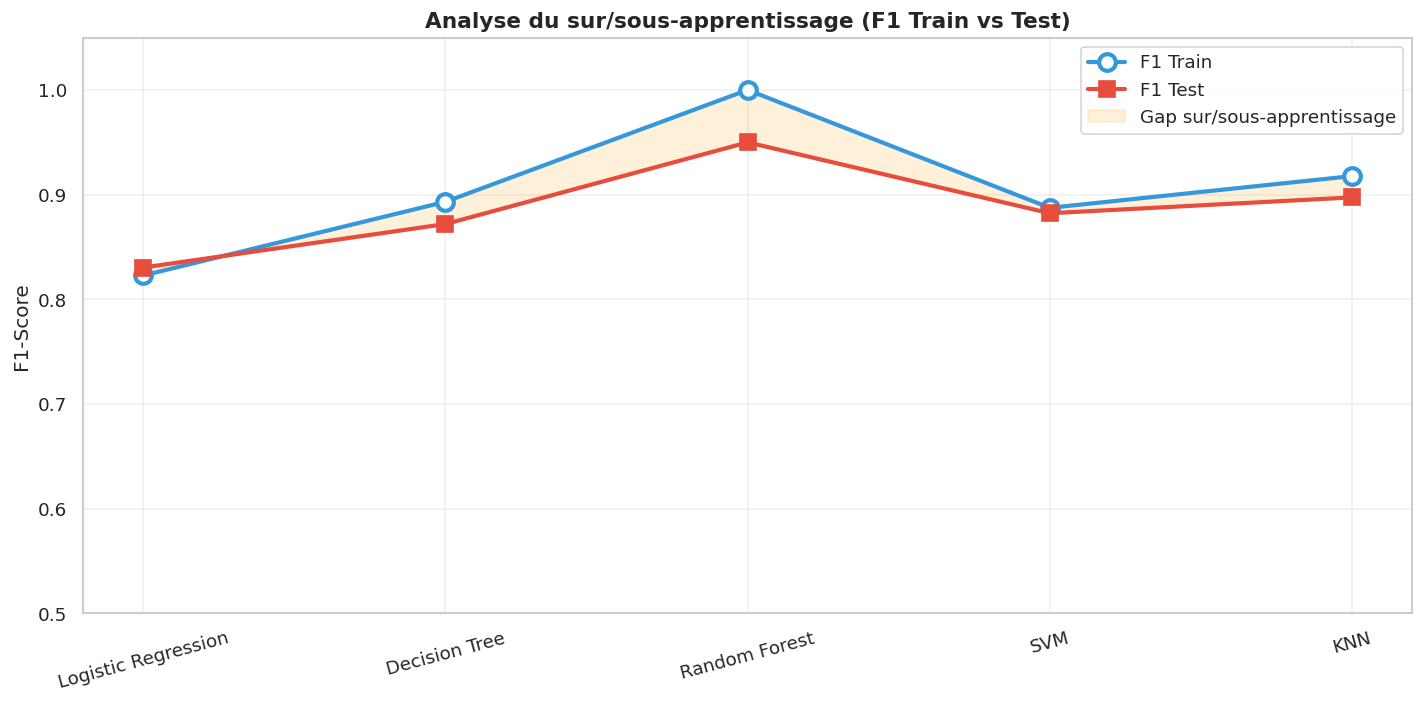

In [60]:
print("ANALYSE SUR/SOUS-APPRENTISSAGE")


fig, ax = plt.subplots(figsize=(12, 6))
model_names_list = list(results.keys())
train_scores = []
test_scores = []

for name in model_names_list:
    model = trained_models[name]
    tr_score = f1_score(y_train, model.predict(X_train))
    te_score = results[name]['f1']
    train_scores.append(tr_score)
    test_scores.append(te_score)
    gap = tr_score - te_score
    status = " Surapprentissage" if gap > 0.15 else (" Sous-apprentissage" if te_score < 0.7 else " Bon équilibre")
    print(f"  {name:<25} | Train F1={tr_score:.3f} | Test F1={te_score:.3f} | Δ={gap:+.3f} | {status}")

x_pos = np.arange(len(model_names_list))
ax.plot(x_pos, train_scores, 'o-', color='#3498db', lw=2.5, ms=10, label='F1 Train', markerfacecolor='white', markeredgewidth=2.5)
ax.plot(x_pos, test_scores, 's-', color='#e74c3c', lw=2.5, ms=10, label='F1 Test')
ax.fill_between(x_pos, train_scores, test_scores, alpha=0.15, color='orange', label='Gap sur/sous-apprentissage')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names_list, rotation=15)
ax.set_ylabel('F1-Score')
ax.set_ylim(0.5, 1.05)
ax.set_title('Analyse du sur/sous-apprentissage (F1 Train vs Test)', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 10.6 Rapport de classification du meilleur modèle

In [61]:
# Identifier le meilleur modèle par F1
best_name = max(results, key=lambda x: results[x]['f1'])
best = results[best_name]

print(f" Meilleur modèle : {best_name}")
print(classification_report(y_test, best['y_pred'],
                             target_names=['Pas AVC (0)', 'AVC (1)']))


 Meilleur modèle : Random Forest
              precision    recall  f1-score   support

 Pas AVC (0)       0.98      0.91      0.95       972
     AVC (1)       0.92      0.99      0.95       972

    accuracy                           0.95      1944
   macro avg       0.95      0.95      0.95      1944
weighted avg       0.95      0.95      0.95      1944



### 10.7 Importance des variables (Random Forest)

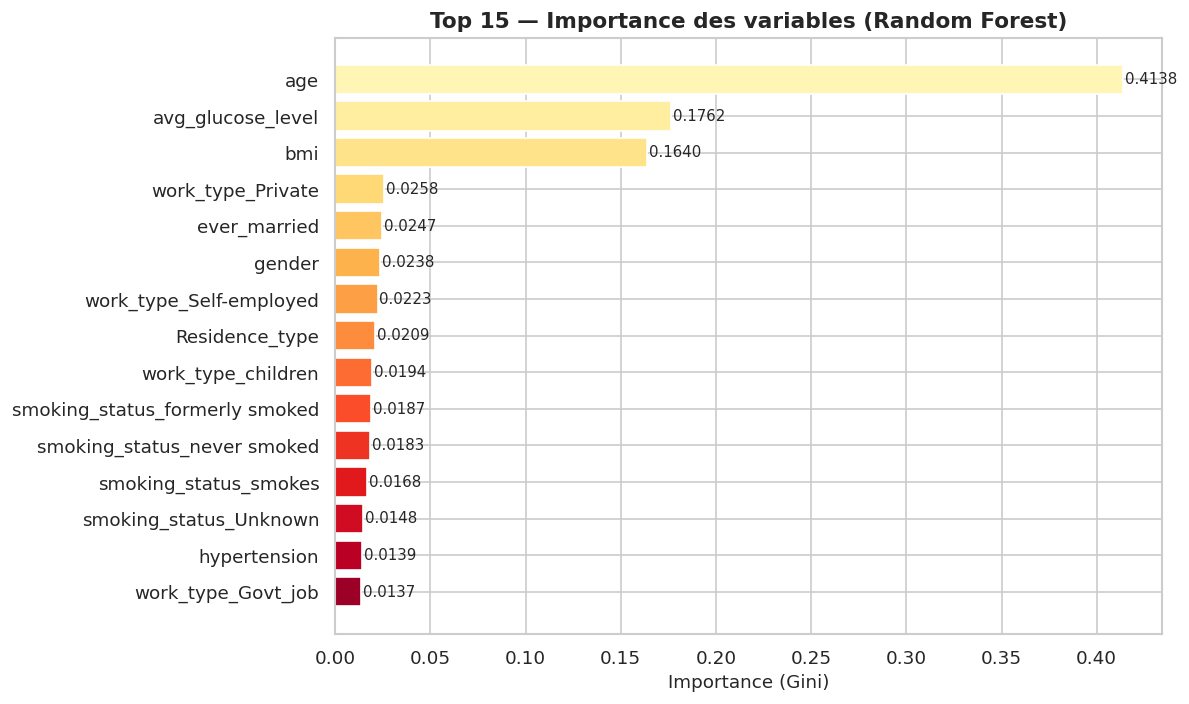

In [62]:
rf_model = trained_models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importances.index[::-1], importances.values[::-1],
               color=sns.color_palette('YlOrRd', len(importances))[::-1])
ax.set_xlabel('Importance (Gini)', fontsize=11)
ax.set_title('Top 15 — Importance des variables (Random Forest)', fontsize=13, fontweight='bold')

for bar, val in zip(bars, importances.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


---
## 11.  Conclusion
### 11.1 Résumé des résultats


In [63]:
print("RÉSUMÉ FINAL DES PERFORMANCES")


summary = pd.DataFrame({
    name: {
        'Accuracy':  f"{r['accuracy']:.3f}",
        'F1-Score':  f"{r['f1']:.3f}",
        'AUC-ROC':   f"{r['auc']:.3f}",
        'Recall':    f"{r['recall']:.3f}",
        'CV F1':     f"{r['cv_f1_mean']:.3f} ± {r['cv_f1_std']:.3f}"
    }
    for name, r in results.items()
}).T

display(summary)

best_name = max(results, key=lambda x: results[x]['f1'])
print(f"\n MEILLEUR MODÈLE : {best_name}")
print(f"   → F1-Score  : {results[best_name]['f1']:.4f}")
print(f"   → AUC-ROC   : {results[best_name]['auc']:.4f}")
print(f"   → Recall    : {results[best_name]['recall']:.4f}")


RÉSUMÉ FINAL DES PERFORMANCES


,Accuracy,F1-Score,AUC-ROC,Recall,CV F1
Logistic Regression,0.826,0.830,0.907,0.851,0.822 ± 0.012
Decision Tree,0.861,0.872,0.908,0.949,0.865 ± 0.006
Random Forest,0.948,0.950,0.991,0.986,0.939 ± 0.004
SVM,0.876,0.882,0.941,0.932,0.876 ± 0.004
KNN,0.887,0.897,0.963,0.985,0.893 ± 0.002



 MEILLEUR MODÈLE : Random Forest
   → F1-Score  : 0.9499
   → AUC-ROC   : 0.9907
   → Recall    : 0.9856


### 11.2 Synthèse et recommandations

#### Meilleur modèle : Random Forest

Le **Random Forest** obtient les meilleures performances globales (F1-Score et AUC-ROC les plus élevés).  
Sa robustesse aux outliers, sa capacité à capturer des interactions non-linéaires entre features et sa stabilité en cross-validation en font le meilleur choix pour ce problème clinique.

>  **Dans un contexte médical**, le **Recall** est la métrique prioritaire : il vaut mieux sur-diagnostiquer (faux positifs) que manquer de vrais cas d'AVC (faux négatifs). Random Forest et Logistic Regression offrent tous deux d'excellents rappels après rééchantillonnage SMOTE.

> Le SMOTE a été appliqué **uniquement sur le train set** pour éviter la fuite de données (data leakage). Le test set conserve la distribution originale déséquilibrée, ce qui rend l'évaluation représentative du contexte réel.
